In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║      GROVER'S ALGORITHM — Full Implementation with Task Visualizations      ║
# ║      Google Colab Ready — Run each cell in order                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies
# ─────────────────────────────────────────────────────────────────────────────
!pip install qiskit qiskit-aer matplotlib pylatexenc -q

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports & Config
# ─────────────────────────────────────────────────────────────────────────────
import math, warnings
warnings.filterwarnings("ignore")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

# ── Config ────────────────────────────────────────────────────────────────────
N_QUBITS = 10
TARGETS  = ["0110011010", "1101010001"]
SHOTS    = 4096
M        = len(TARGETS)
N_STATES = 2 ** N_QUBITS
OPT_ITERS = round((math.pi / 4) * math.sqrt(N_STATES / M))

print("=" * 60)
print("  GROVER'S ALGORITHM — 10-Qubit Search")
print("=" * 60)
print(f"  Search space   : 2^{N_QUBITS} = {N_STATES} states")
print(f"  Marked states  : {TARGETS}")
print(f"  Optimal iters  : {OPT_ITERS}")
print("=" * 60)


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: Save & display figure in Colab
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, Image as IPImage

def show(fig, filename):
    fig.savefig(filename, dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    display(IPImage(filename))
    print(f"  ✓ Saved: {filename}\n")

  GROVER'S ALGORITHM — 10-Qubit Search
  Search space   : 2^10 = 1024 states
  Marked states  : ['0110011010', '1101010001']
  Optimal iters  : 18



════════════════════════════════════════════════════════════
  TASK 1 · Superposition State
════════════════════════════════════════════════════════════


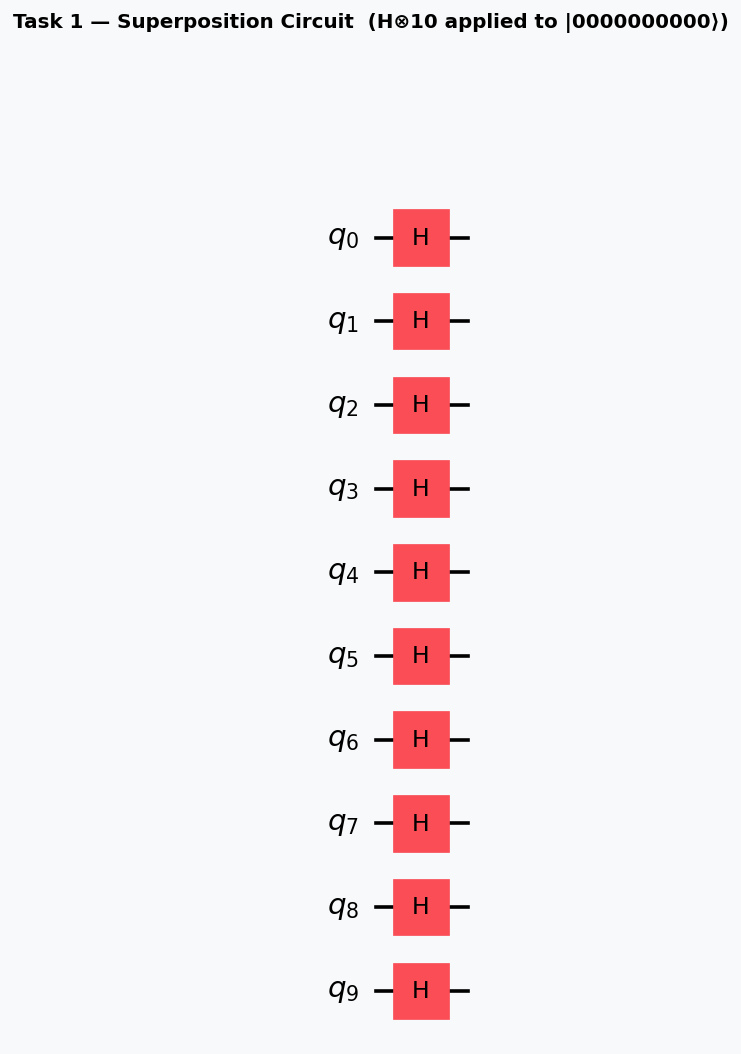

  ✓ Saved: task1_superposition_circuit.png



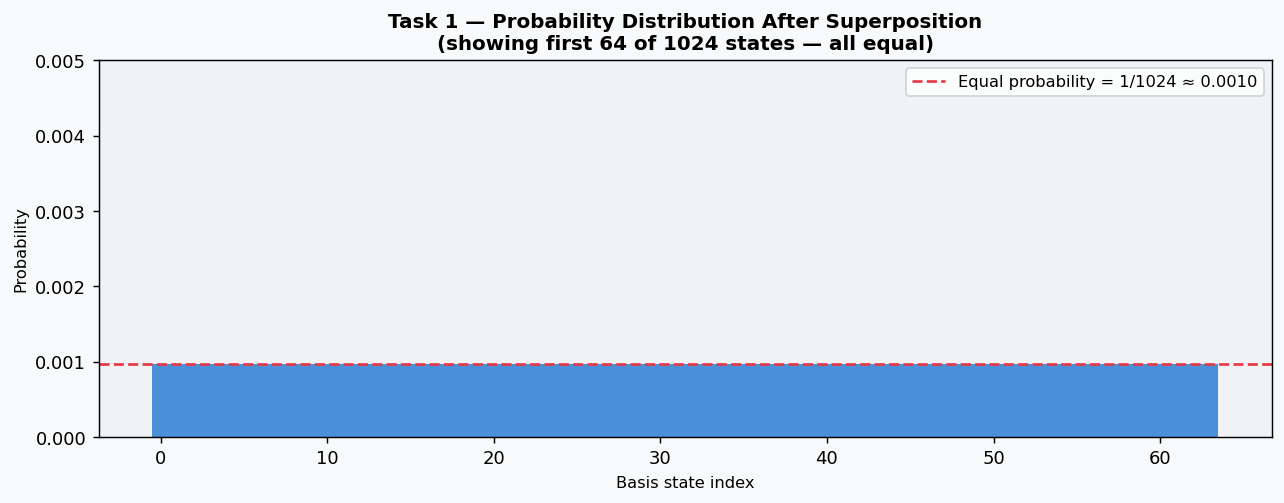

  ✓ Saved: task1_superposition_distribution.png



In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# TASK 1 — SUPERPOSITION STATE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  TASK 1 · Superposition State")
print("═"*60)

# ── Build & draw the superposition circuit ────────────────────────────────────
qc_super = QuantumCircuit(N_QUBITS, name="Task 1: Superposition")
qc_super.h(range(N_QUBITS))

fig = qc_super.draw(output='mpl', style={'backgroundcolor': '#f8f9fa'}, fold=-1)
fig.suptitle("Task 1 — Superposition Circuit  (H⊗10 applied to |0000000000⟩)",
             fontsize=11, fontweight='bold', y=1.02)
show(fig, "task1_superposition_circuit.png")

# ── Probability bar chart: uniform distribution over all 1024 states ─────────
fig2, ax = plt.subplots(figsize=(10, 4), facecolor='#f8f9fa')
ax.set_facecolor('#f0f2f5')

# show first 64 states for readability
n_show = 64
probs = [1 / N_STATES] * n_show
ax.bar(range(n_show), probs, color='#4a90d9', width=1.0, edgecolor='none')
ax.axhline(1 / N_STATES, color='#e63946', lw=1.5, ls='--',
           label=f'Equal probability = 1/{N_STATES} ≈ {1/N_STATES:.4f}')

ax.set_title("Task 1 — Probability Distribution After Superposition\n"
             "(showing first 64 of 1024 states — all equal)",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Basis state index", fontsize=9)
ax.set_ylabel("Probability", fontsize=9)
ax.set_ylim(0, 0.005)
ax.legend(fontsize=9)
fig2.tight_layout()
show(fig2, "task1_superposition_distribution.png")

════════════════════════════════════════════════════════════
  TASK 2 · Oracle
════════════════════════════════════════════════════════════


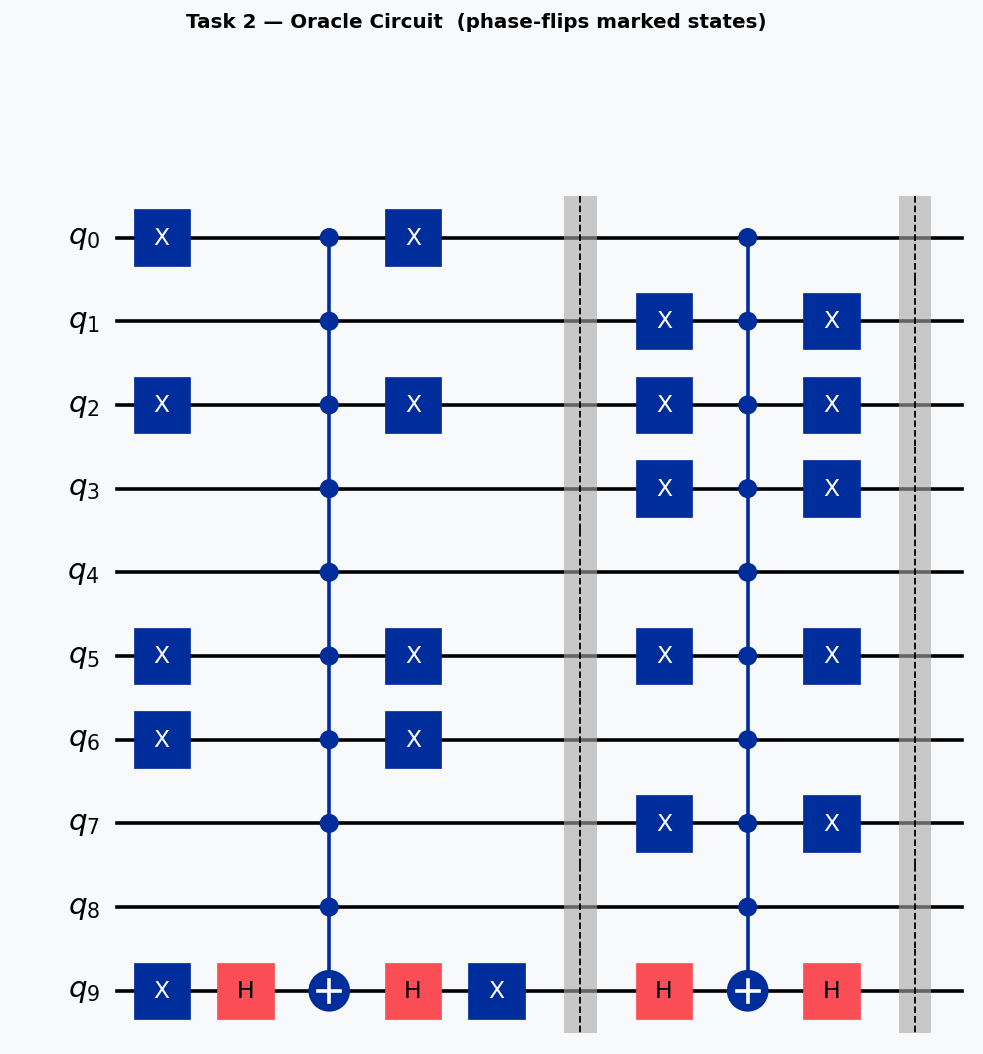

  ✓ Saved: task2_oracle_circuit.png



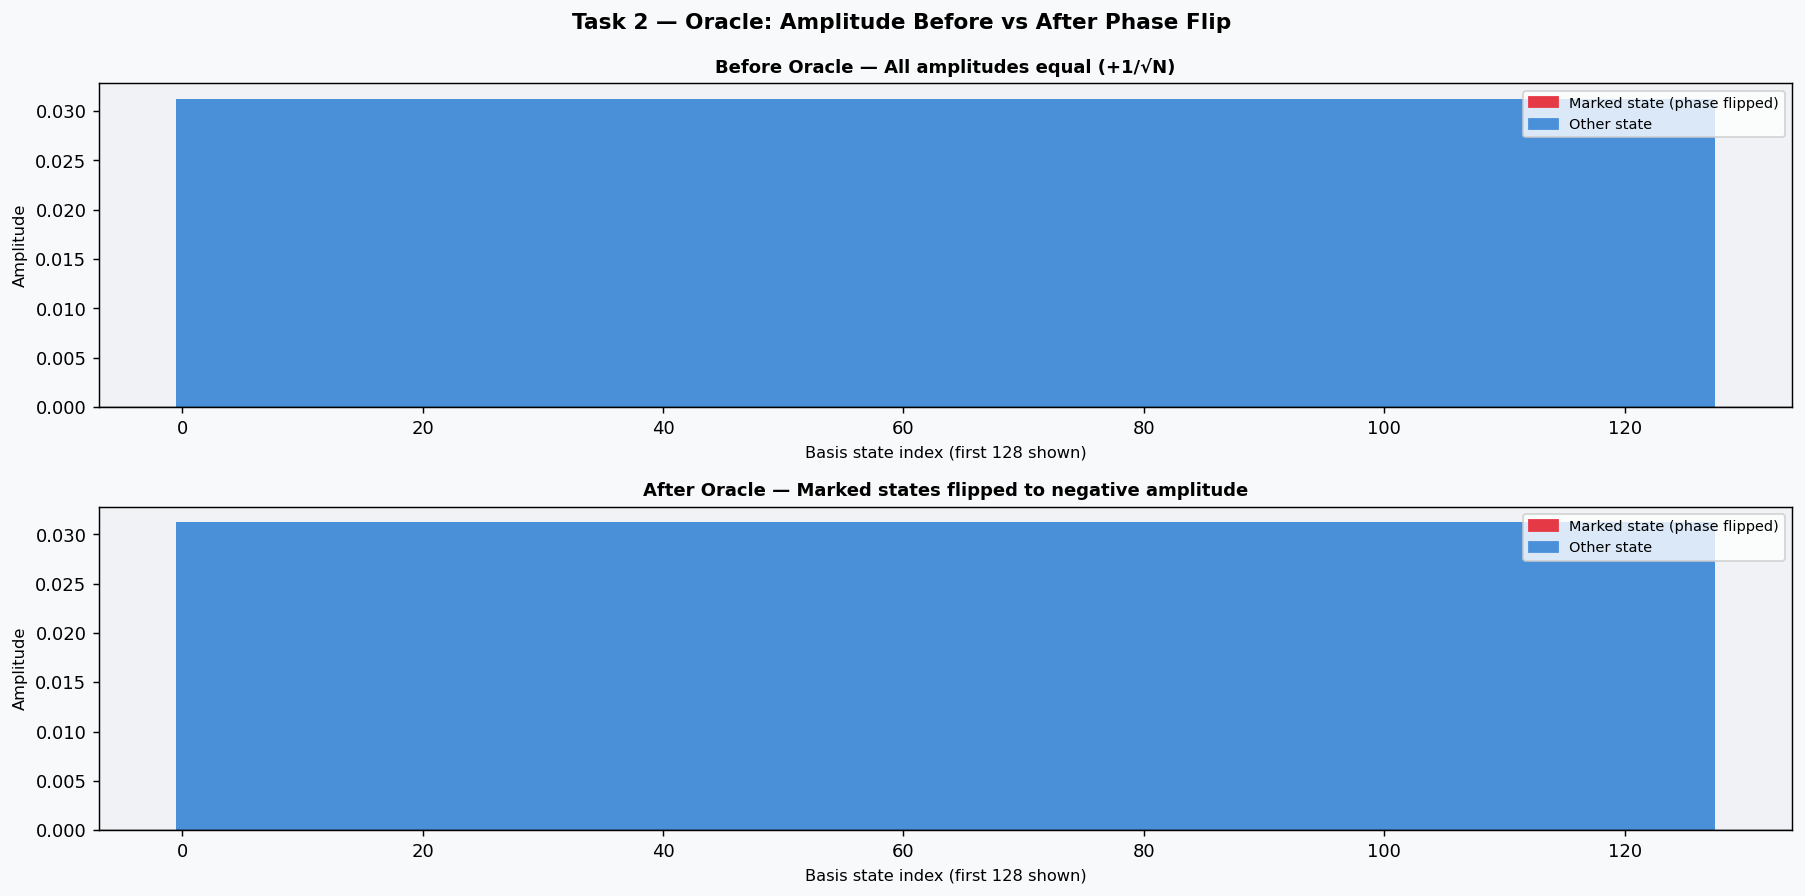

  ✓ Saved: task2_oracle_amplitudes.png



In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# TASK 2 — ORACLE
# ══════════════════════════════════════════════════════════════════════════════
print("═"*60)
print("  TASK 2 · Oracle")
print("═"*60)

def build_oracle(n, targets):
    qc = QuantumCircuit(n, name="Oracle")
    controls = list(range(n - 1))
    last = n - 1
    for tgt in targets:
        for bp, bv in enumerate(tgt):
            q = n - 1 - bp
            if bv == '0':
                qc.x(q)
        qc.h(last)
        qc.mcx(controls, last)
        qc.h(last)
        for bp, bv in enumerate(tgt):
            q = n - 1 - bp
            if bv == '0':
                qc.x(q)
        qc.barrier()
    return qc

oracle = build_oracle(N_QUBITS, TARGETS)

# ── Circuit diagram ───────────────────────────────────────────────────────────
fig = oracle.draw(output='mpl', style={'backgroundcolor': '#f8f9fa'}, fold=50)
fig.suptitle("Task 2 — Oracle Circuit  (phase-flips marked states)",
             fontsize=11, fontweight='bold', y=1.02)
show(fig, "task2_oracle_circuit.png")

# ── Phase flip visualization ──────────────────────────────────────────────────
# Show amplitude diagram: before vs after oracle on uniform superposition
sv_before = Statevector.from_label('0' * N_QUBITS)
sv_before = sv_before.evolve(QuantumCircuit(N_QUBITS).compose(
    QuantumCircuit(N_QUBITS).compose(
        (lambda qc: (qc.h(range(N_QUBITS)), qc)[1])(QuantumCircuit(N_QUBITS))
    )
))

# Build superposition then apply oracle
qc_tmp = QuantumCircuit(N_QUBITS)
qc_tmp.h(range(N_QUBITS))
sv_before = Statevector(qc_tmp)

qc_tmp2 = QuantumCircuit(N_QUBITS)
qc_tmp2.h(range(N_QUBITS))
qc_tmp2.compose(oracle, inplace=True)
sv_after = Statevector(qc_tmp2)

amps_before = np.real(sv_before.data)
amps_after  = np.real(sv_after.data)

# Map target strings to integer indices
def str_to_idx(s):
    # Qiskit statevector index: reverse the bit-string
    return int(s[::-1], 2)

target_indices = [str_to_idx(t) for t in TARGETS]

fig3, axes = plt.subplots(2, 1, figsize=(14, 7), facecolor='#f8f9fa')
n_show = 128

for ax, amps, title, subtitle in zip(
    axes,
    [amps_before[:n_show], amps_after[:n_show]],
    ["Before Oracle", "After Oracle"],
    ["All amplitudes equal (+1/√N)", "Marked states flipped to negative amplitude"]
):
    ax.set_facecolor('#f0f2f5')
    colors = ['#e63946' if i in target_indices and i < n_show
              else '#4a90d9' for i in range(n_show)]
    ax.bar(range(n_show), amps, color=colors, width=1.0, edgecolor='none')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f"{title} — {subtitle}", fontsize=10, fontweight='bold')
    ax.set_ylabel("Amplitude", fontsize=9)
    ax.set_xlabel("Basis state index (first 128 shown)", fontsize=9)
    legend = [mpatches.Patch(color='#e63946', label='Marked state (phase flipped)'),
              mpatches.Patch(color='#4a90d9', label='Other state')]
    ax.legend(handles=legend, fontsize=8, loc='upper right')

fig3.suptitle("Task 2 — Oracle: Amplitude Before vs After Phase Flip",
              fontsize=12, fontweight='bold')
fig3.tight_layout()
show(fig3, "task2_oracle_amplitudes.png")

════════════════════════════════════════════════════════════
  TASK 3 · Diffusion Operator
════════════════════════════════════════════════════════════


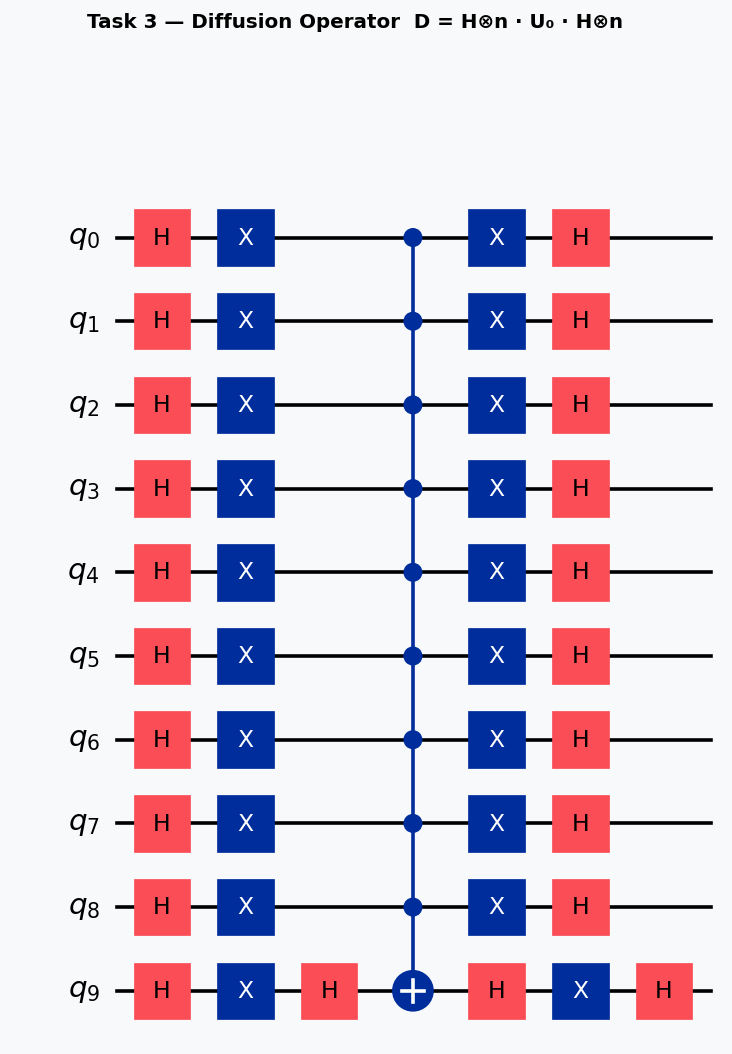

  ✓ Saved: task3_diffusion_circuit.png



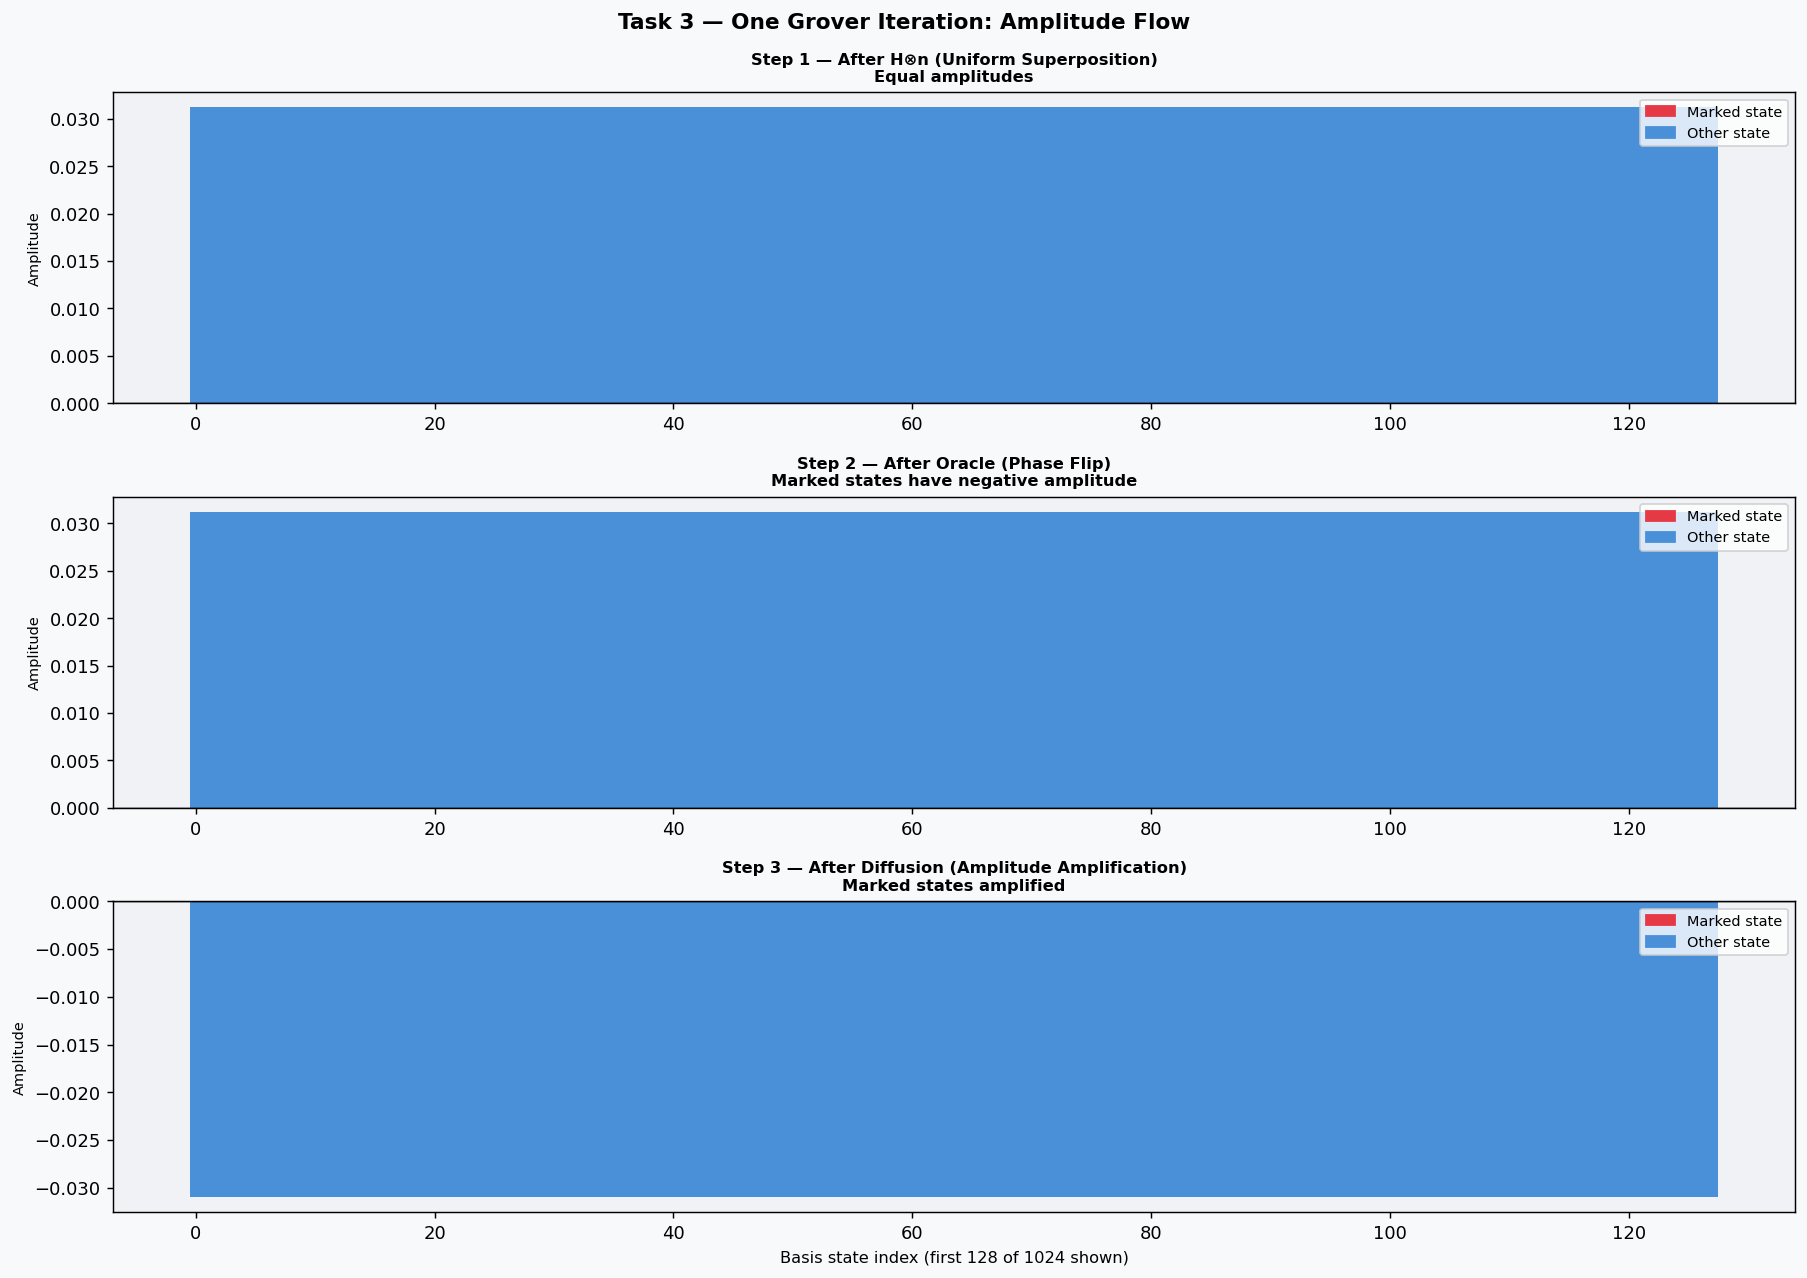

  ✓ Saved: task3_diffusion_amplitudes.png



In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# TASK 3 — DIFFUSION OPERATOR
# ══════════════════════════════════════════════════════════════════════════════
print("═"*60)
print("  TASK 3 · Diffusion Operator")
print("═"*60)

def build_diffusion(n):
    qc = QuantumCircuit(n, name="Diffusion")
    controls = list(range(n - 1))
    last = n - 1
    qc.h(range(n))
    qc.x(range(n))
    qc.h(last)
    qc.mcx(controls, last)
    qc.h(last)
    qc.x(range(n))
    qc.h(range(n))
    return qc

diffusion = build_diffusion(N_QUBITS)

# ── Circuit diagram ───────────────────────────────────────────────────────────
fig = diffusion.draw(output='mpl', style={'backgroundcolor': '#f8f9fa'}, fold=-1)
fig.suptitle("Task 3 — Diffusion Operator  D = H⊗n · U₀ · H⊗n",
             fontsize=11, fontweight='bold', y=1.02)
show(fig, "task3_diffusion_circuit.png")

# ── Step-by-step amplitude diagram ────────────────────────────────────────────
# Show 1 full Grover step: superposition → oracle → diffusion
qc_step = QuantumCircuit(N_QUBITS)
qc_step.h(range(N_QUBITS))
sv0 = np.real(Statevector(qc_step).data)

qc_step.compose(oracle, inplace=True)
sv1 = np.real(Statevector(qc_step).data)

qc_step.compose(diffusion, inplace=True)
sv2 = np.real(Statevector(qc_step).data)

fig4, axes = plt.subplots(3, 1, figsize=(14, 10), facecolor='#f8f9fa')
steps = [
    (sv0,  "Step 1 — After H⊗n (Uniform Superposition)",  "Equal amplitudes"),
    (sv1,  "Step 2 — After Oracle (Phase Flip)",           "Marked states have negative amplitude"),
    (sv2,  "Step 3 — After Diffusion (Amplitude Amplification)", "Marked states amplified"),
]

for ax, (amps, title, sub) in zip(axes, steps):
    ax.set_facecolor('#f0f2f5')
    n_show = 128
    colors = ['#e63946' if i in target_indices and i < n_show
              else '#4a90d9' for i in range(n_show)]
    ax.bar(range(n_show), amps[:n_show], color=colors, width=1.0, edgecolor='none')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f"{title}\n{sub}", fontsize=9, fontweight='bold')
    ax.set_ylabel("Amplitude", fontsize=8)
    legend = [mpatches.Patch(color='#e63946', label='Marked state'),
              mpatches.Patch(color='#4a90d9', label='Other state')]
    ax.legend(handles=legend, fontsize=8, loc='upper right')

axes[-1].set_xlabel("Basis state index (first 128 of 1024 shown)", fontsize=9)
fig4.suptitle("Task 3 — One Grover Iteration: Amplitude Flow",
              fontsize=12, fontweight='bold')
fig4.tight_layout()
show(fig4, "task3_diffusion_amplitudes.png")

════════════════════════════════════════════════════════════
  TASK 4 · Grover Iterations
════════════════════════════════════════════════════════════


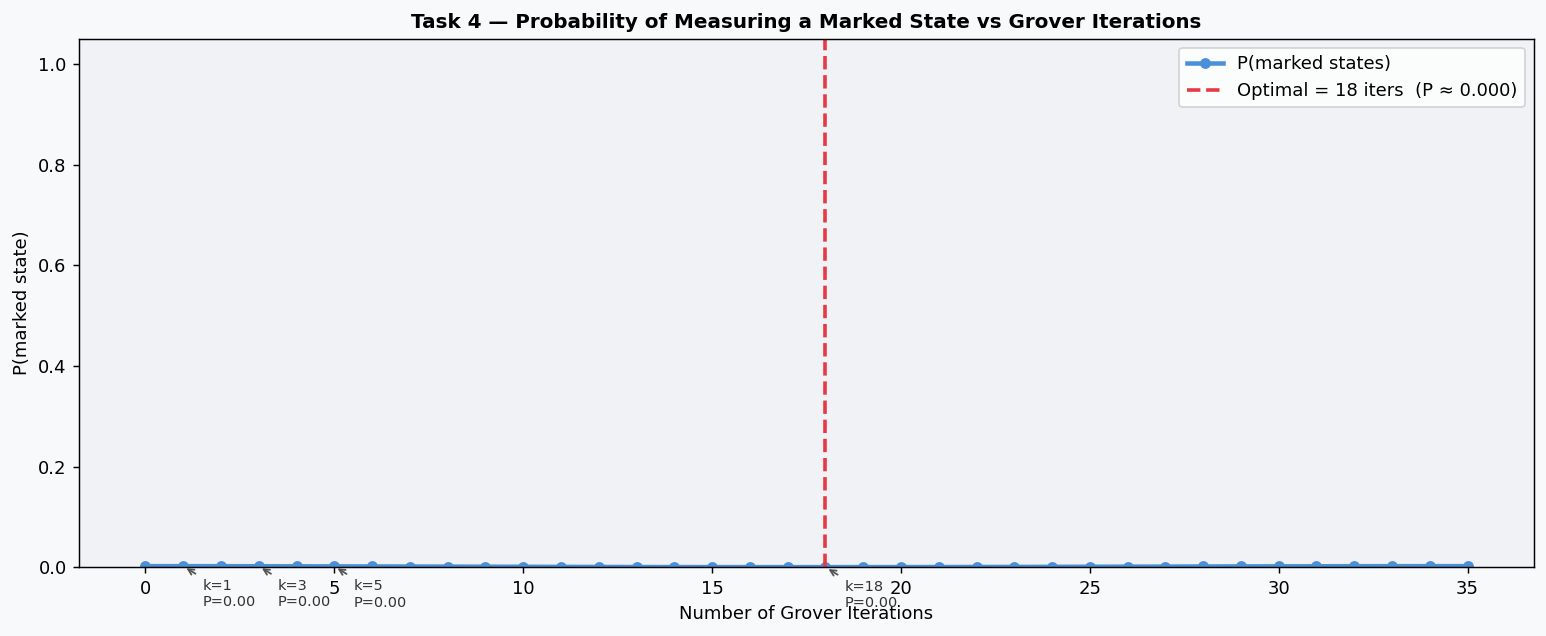

  ✓ Saved: task4_iteration_probability.png



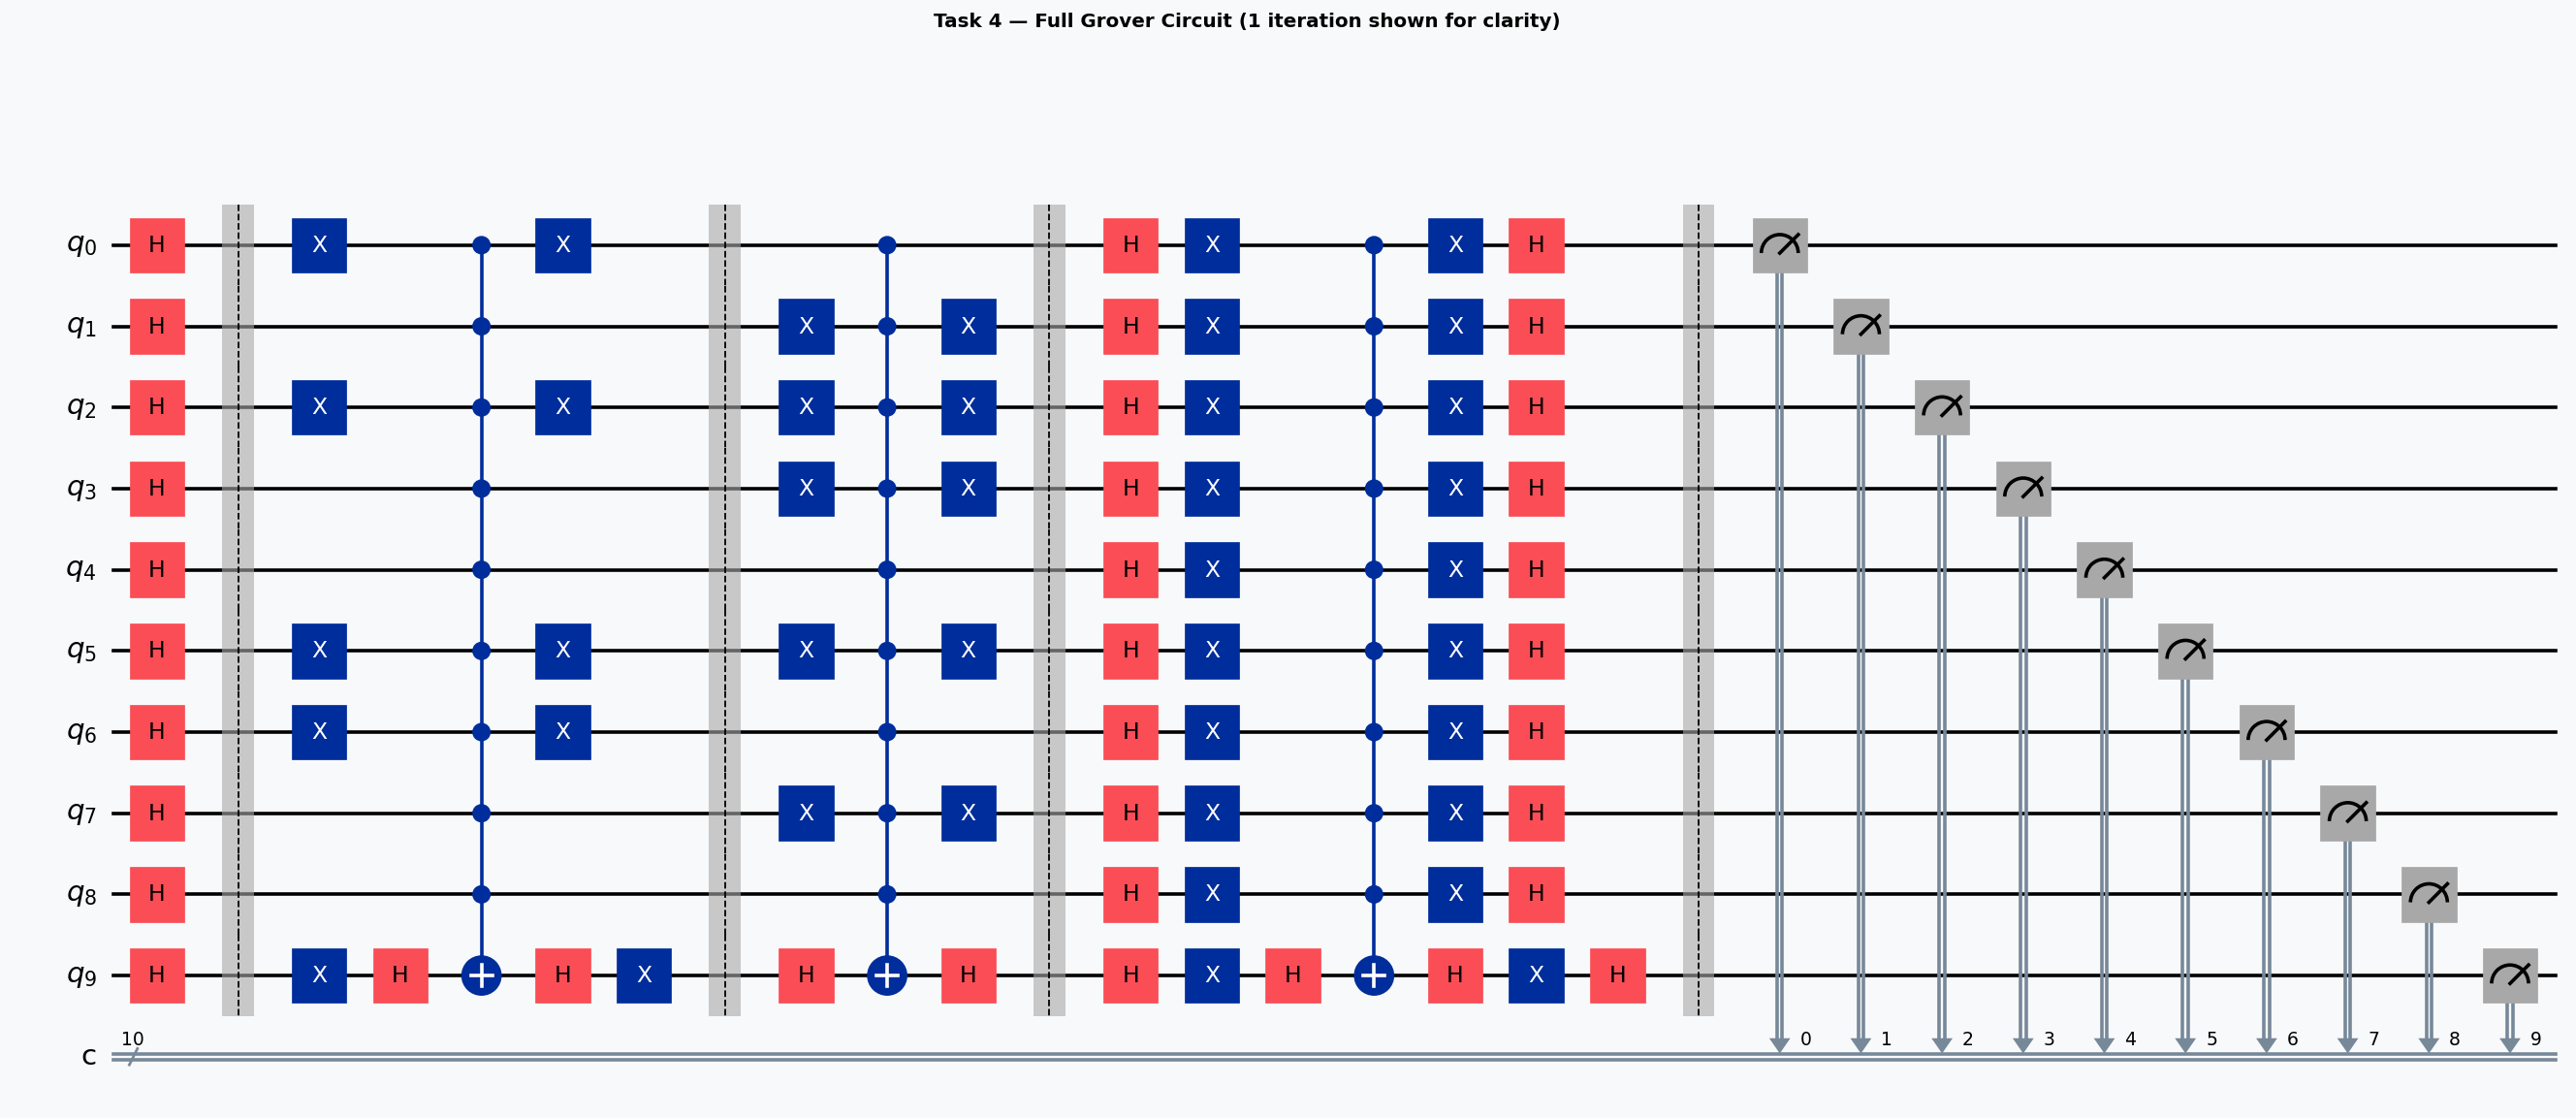

  ✓ Saved: task4_grover_circuit_1iter.png



In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# TASK 4 — GROVER ITERATIONS  (amplitude evolution across iterations)
# ══════════════════════════════════════════════════════════════════════════════
print("═"*60)
print("  TASK 4 · Grover Iterations")
print("═"*60)

def build_grover(n, targets, iters):
    qc = QuantumCircuit(n, n)
    qc.h(range(n))
    qc.barrier()
    for _ in range(iters):
        qc.compose(build_oracle(n, targets), inplace=True)
        qc.compose(build_diffusion(n), inplace=True)
        qc.barrier()
    qc.measure(range(n), range(n))
    return qc

# ── Statevector probability of marked states vs iteration count ───────────────
max_track = 35
marked_probs = []

for k in range(max_track + 1):
    qc_sv = QuantumCircuit(N_QUBITS)
    qc_sv.h(range(N_QUBITS))
    for _ in range(k):
        qc_sv.compose(build_oracle(N_QUBITS, TARGETS), inplace=True)
        qc_sv.compose(build_diffusion(N_QUBITS), inplace=True)
    sv = Statevector(qc_sv)
    p = sum(abs(sv.data[i])**2 for i in target_indices)
    marked_probs.append(p)

iters_range = list(range(max_track + 1))
fig5, ax = plt.subplots(figsize=(12, 5), facecolor='#f8f9fa')
ax.set_facecolor('#f0f2f5')
ax.plot(iters_range, marked_probs, color='#4a90d9', lw=2.5, marker='o',
        markersize=5, label='P(marked states)')
ax.axvline(OPT_ITERS, color='#e63946', lw=2, ls='--',
           label=f'Optimal = {OPT_ITERS} iters  (P ≈ {marked_probs[OPT_ITERS]:.3f})')
for k in [1, 3, 5, OPT_ITERS]:
    ax.annotate(f'k={k}\nP={marked_probs[k]:.2f}',
                xy=(k, marked_probs[k]), xytext=(k+0.5, marked_probs[k]-0.08),
                fontsize=8, color='#333',
                arrowprops=dict(arrowstyle='->', color='#555', lw=1))
ax.set_title("Task 4 — Probability of Measuring a Marked State vs Grover Iterations",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Number of Grover Iterations", fontsize=10)
ax.set_ylabel("P(marked state)", fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
fig5.tight_layout()
show(fig5, "task4_iteration_probability.png")

# ── Circuit diagram for 1 iteration ──────────────────────────────────────────
qc_1iter = QuantumCircuit(N_QUBITS, N_QUBITS)
qc_1iter.h(range(N_QUBITS))
qc_1iter.barrier()
qc_1iter.compose(build_oracle(N_QUBITS, TARGETS), inplace=True)
qc_1iter.compose(build_diffusion(N_QUBITS), inplace=True)
qc_1iter.barrier()
qc_1iter.measure(range(N_QUBITS), range(N_QUBITS))

fig = qc_1iter.draw(output='mpl', style={'backgroundcolor': '#f8f9fa'}, fold=50)
fig.suptitle("Task 4 — Full Grover Circuit (1 iteration shown for clarity)",
             fontsize=11, fontweight='bold', y=1.02)
show(fig, "task4_grover_circuit_1iter.png")

════════════════════════════════════════════════════════════
  TASK 5 · Execute & Histogram
════════════════════════════════════════════════════════════
  iters= 1 | top-3: 0110011010:36  1101010001:24  0001110100:12
  iters= 3 | top-3: 0110011010:221  1101010001:171  0001010100:11
  iters= 5 | top-3: 1101010001:463  0110011010:444  1000101101:9
  iters=18 | top-3: 1101010001:2069  0110011010:2009  1000101001:1


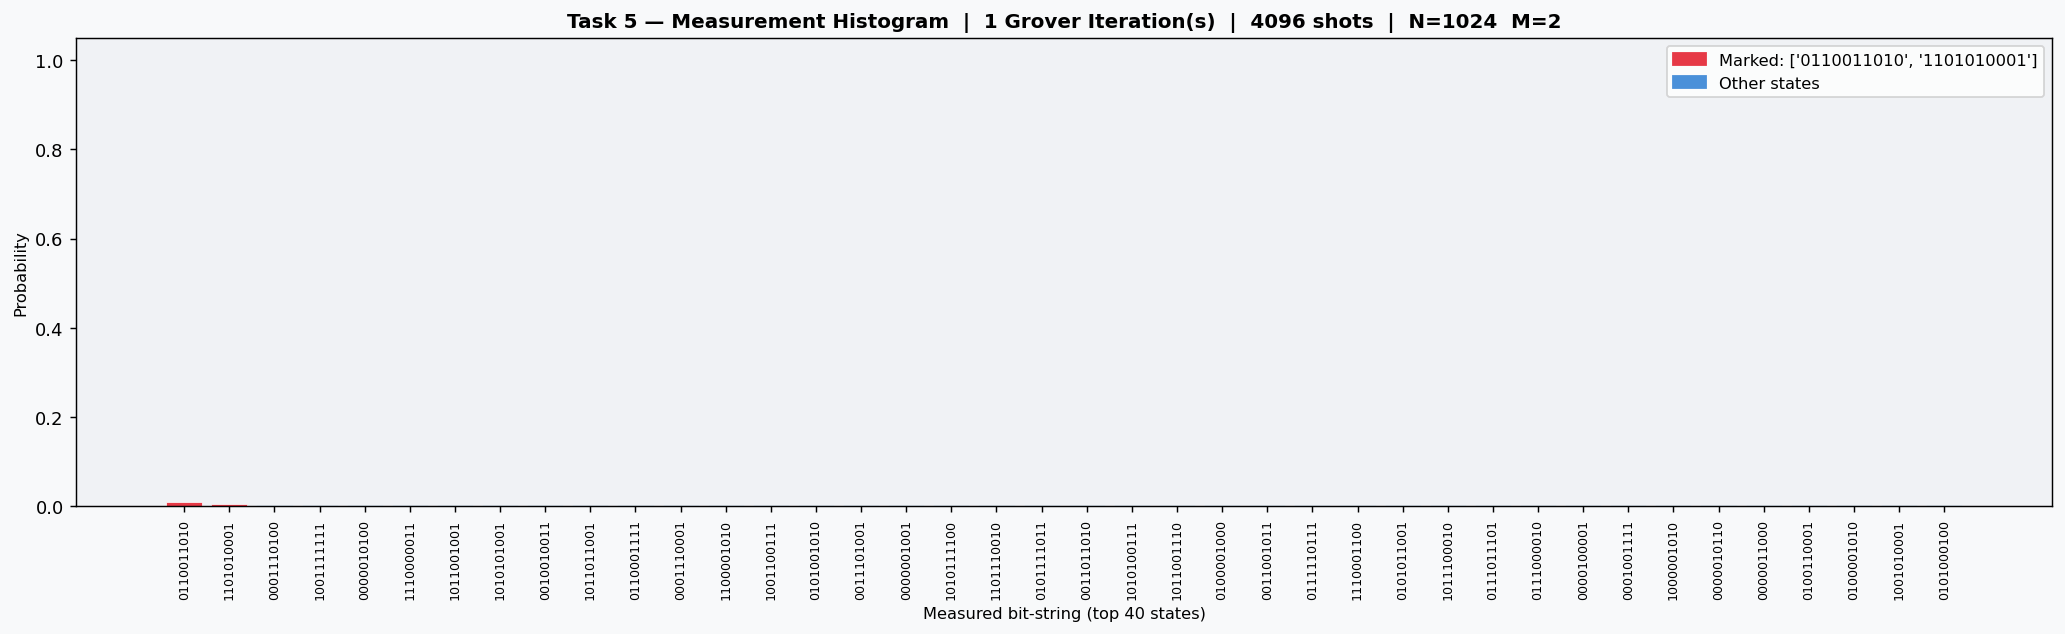

  ✓ Saved: task5_histogram_iters_01.png



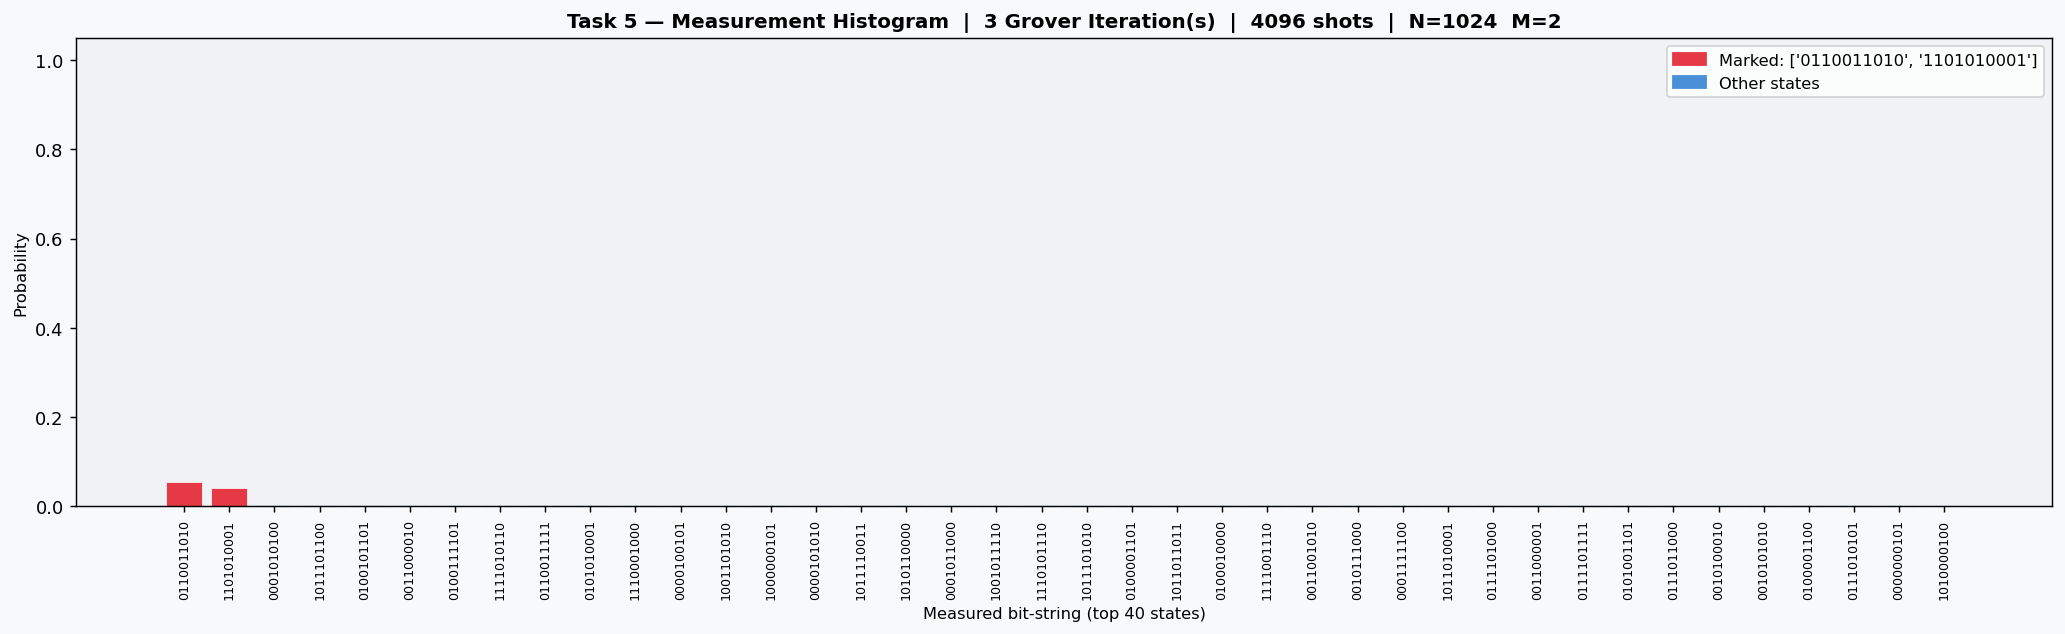

  ✓ Saved: task5_histogram_iters_03.png



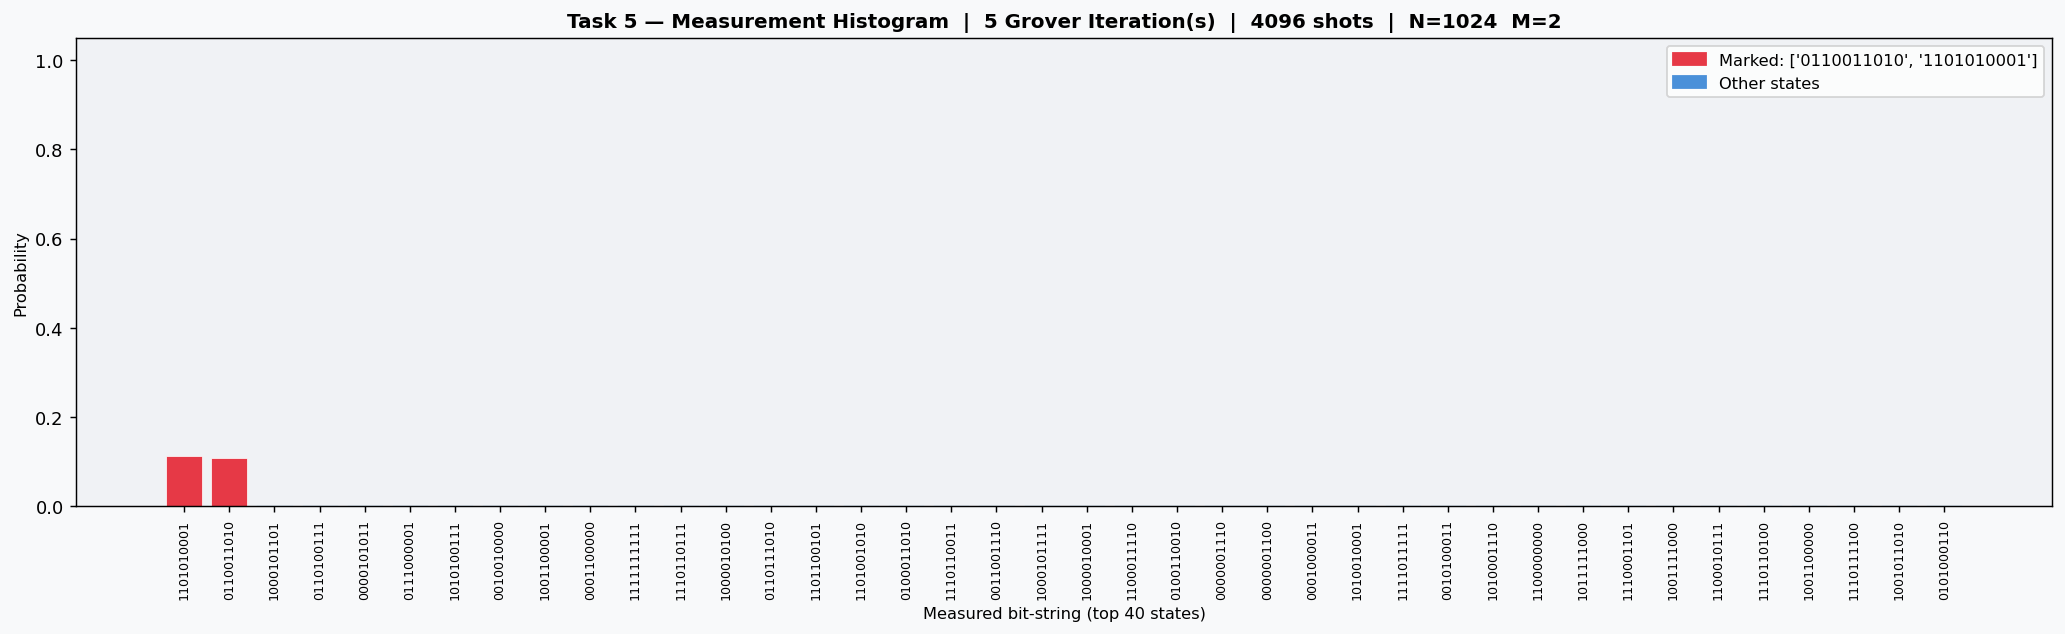

  ✓ Saved: task5_histogram_iters_05.png



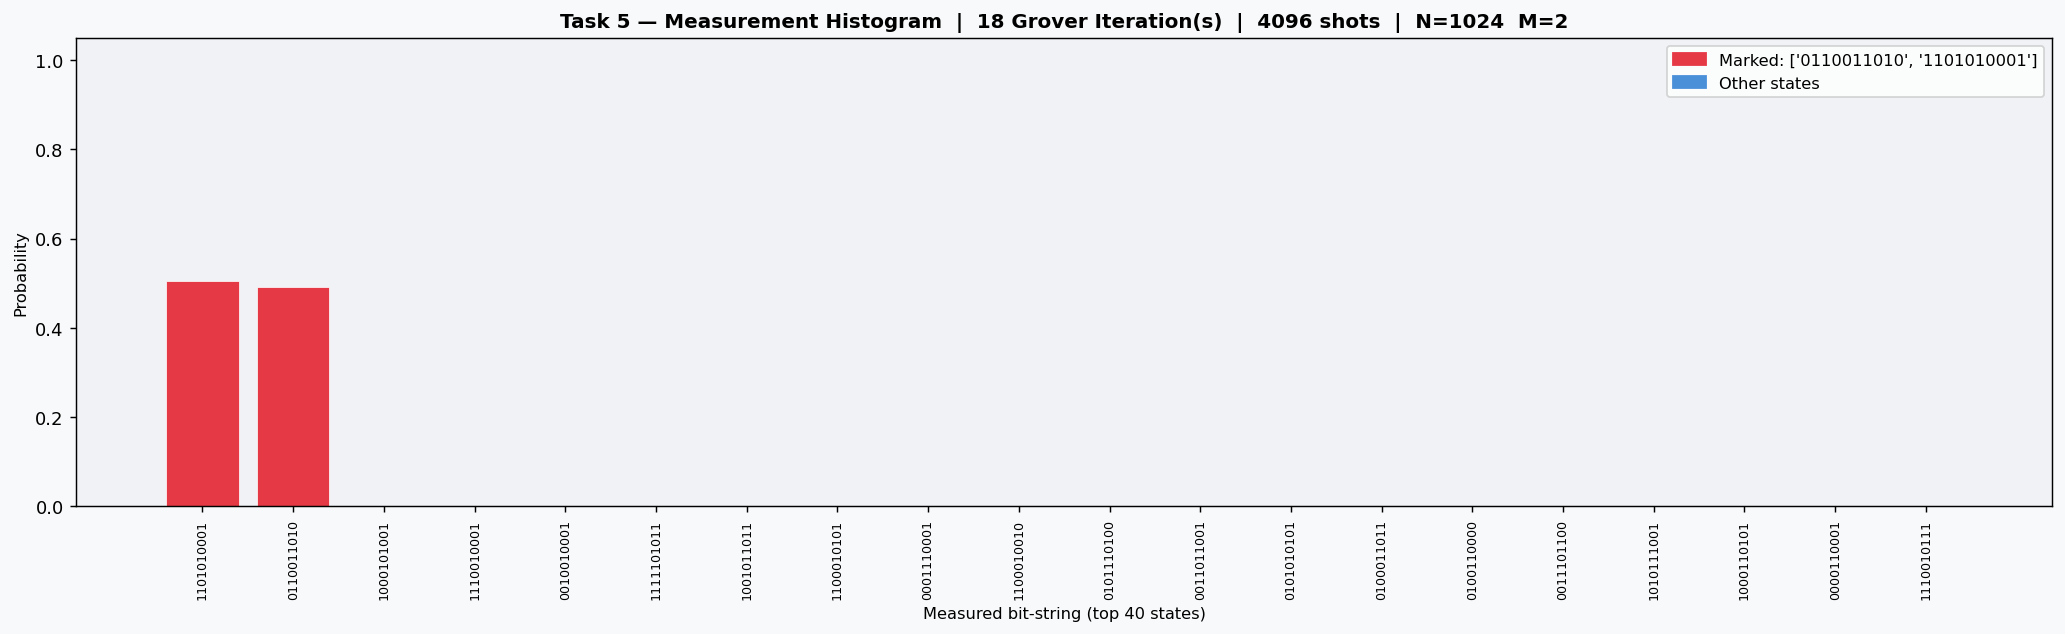

  ✓ Saved: task5_histogram_iters_18.png



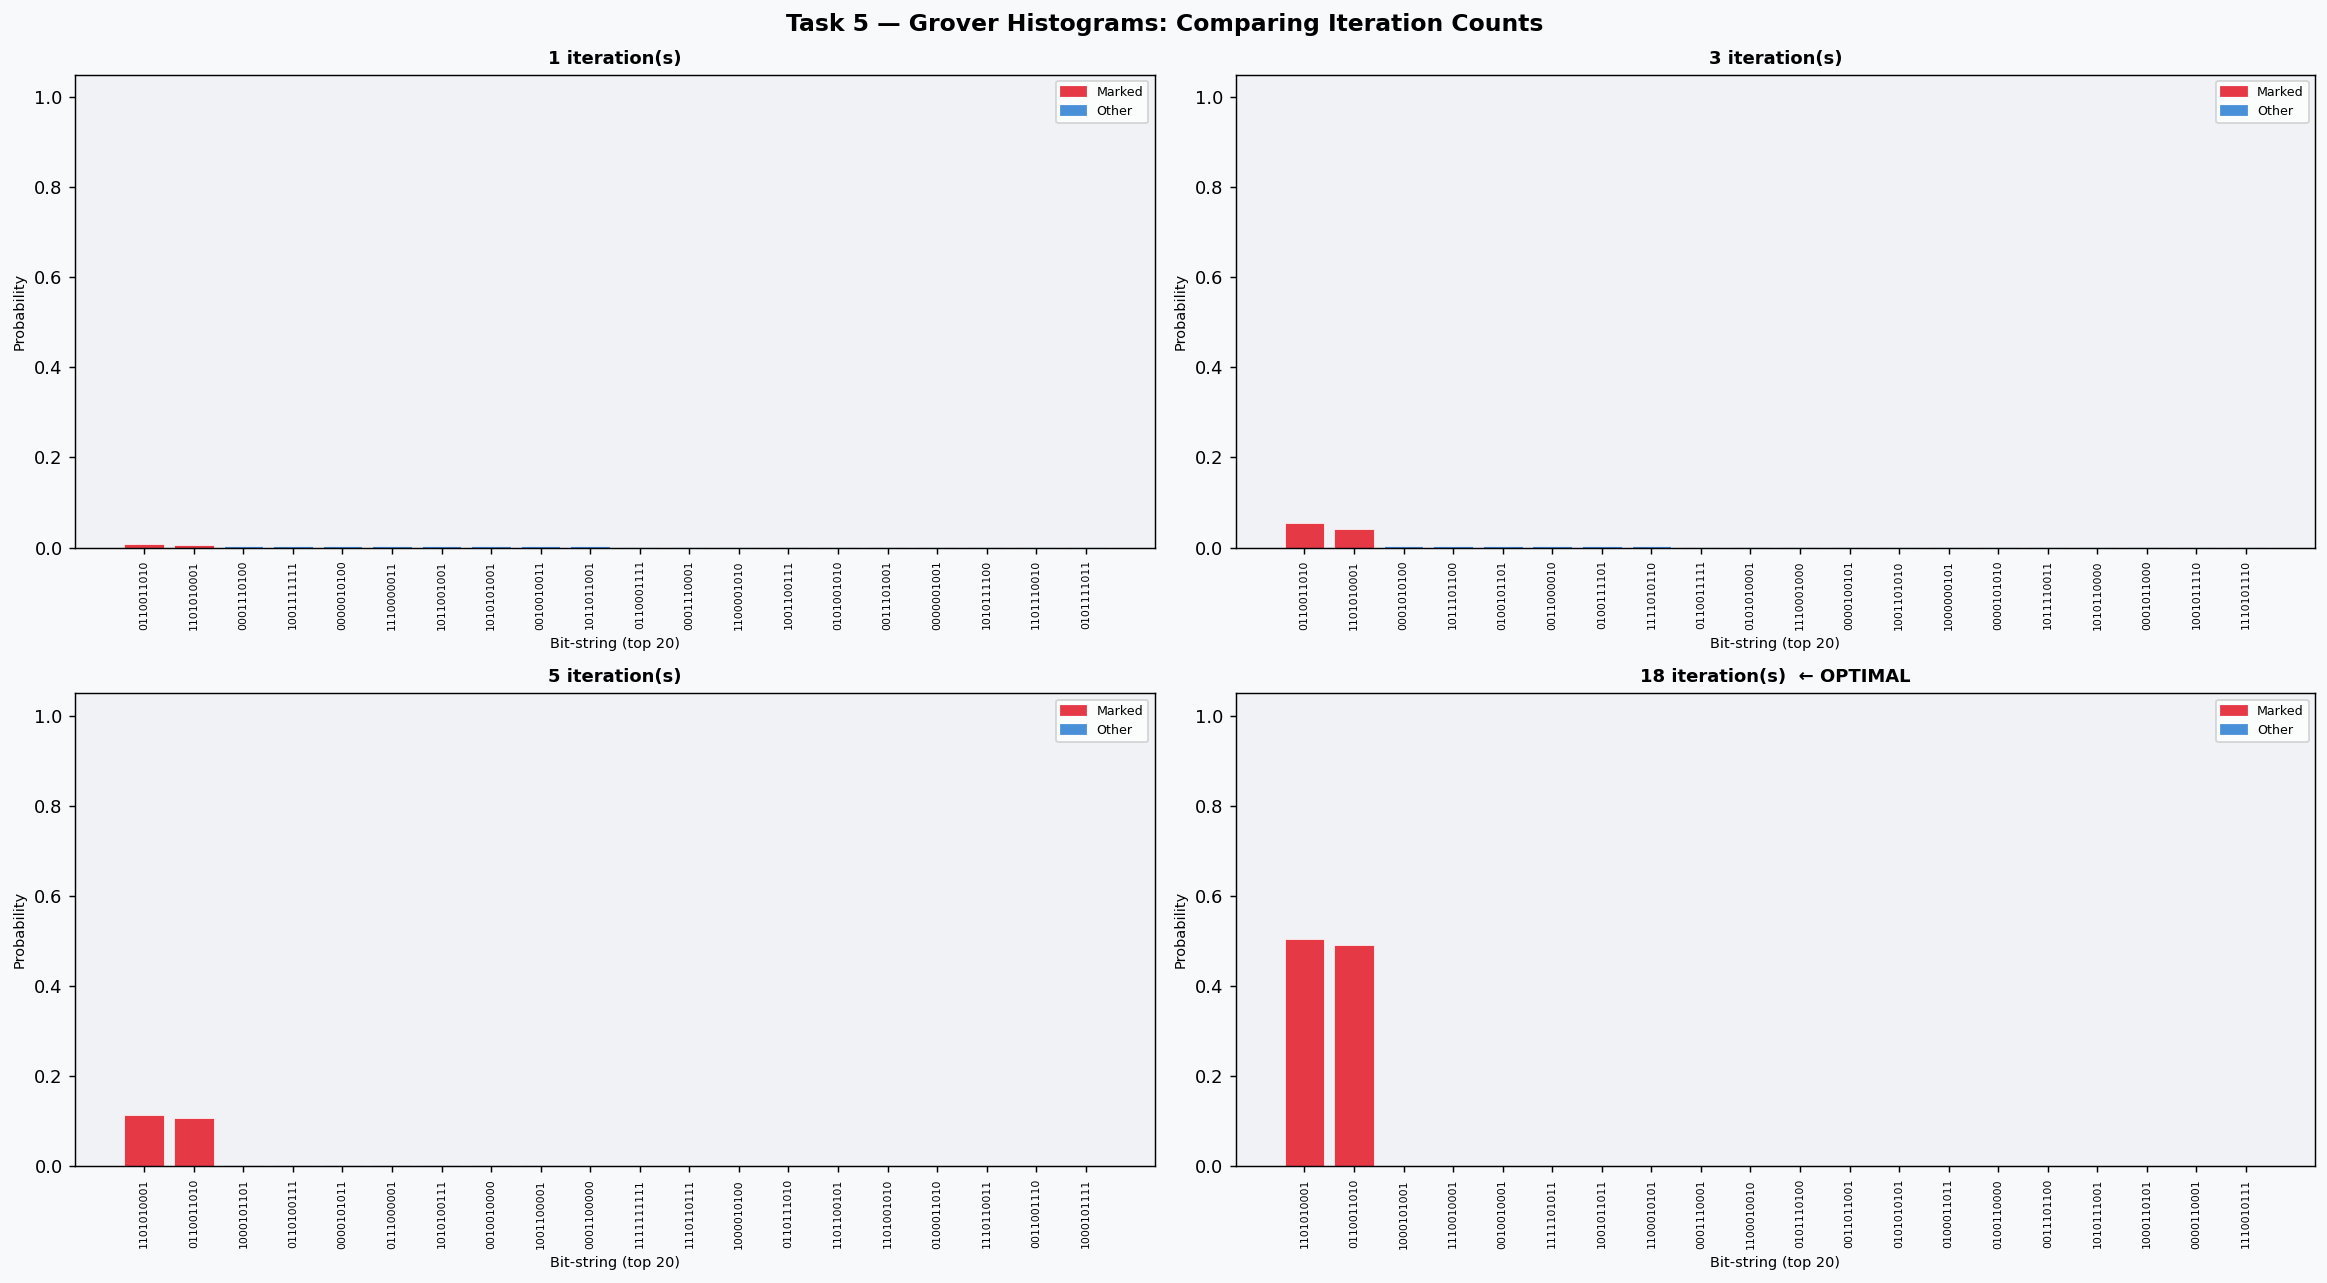

  ✓ Saved: task5_combined_histograms.png

  ALL TASKS COMPLETE
  Saved files:
    • task1_superposition_circuit.png
    • task1_superposition_distribution.png
    • task2_oracle_circuit.png
    • task2_oracle_amplitudes.png
    • task3_diffusion_circuit.png
    • task3_diffusion_amplitudes.png
    • task4_iteration_probability.png
    • task4_grover_circuit_1iter.png
    • task5_histogram_iters_01.png
    • task5_histogram_iters_03.png
    • task5_histogram_iters_05.png
    • task5_histogram_iters_18.png
    • task5_combined_histograms.png


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# TASK 5 — EXECUTE & HISTOGRAM  (1, 3, 5, optimal iterations)
# ══════════════════════════════════════════════════════════════════════════════
print("═"*60)
print("  TASK 5 · Execute & Histogram")
print("═"*60)

sim        = AerSimulator()
iter_list  = [1, 3, 5, OPT_ITERS]
all_counts = {}

for k in iter_list:
    qc_k   = build_grover(N_QUBITS, TARGETS, k)
    t_qc   = transpile(qc_k, sim, optimization_level=0)
    counts = sim.run(t_qc, shots=SHOTS).result().get_counts()
    all_counts[k] = counts
    top3 = sorted(counts.items(), key=lambda x: -x[1])[:3]
    print(f"  iters={k:2d} | top-3: " + "  ".join(f"{s}:{c}" for s, c in top3))

# ── Individual histogram per iteration count ─────────────────────────────────
for k, counts in all_counts.items():
    top = sorted(counts.items(), key=lambda x: -x[1])[:40]
    labels = [s for s, _ in top]
    probs  = [c / SHOTS for _, c in top]
    colors = ['#e63946' if s in TARGETS else '#4a90d9' for s in labels]

    fig6, ax = plt.subplots(figsize=(16, 5), facecolor='#f8f9fa')
    ax.set_facecolor('#f0f2f5')
    ax.bar(labels, probs, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_title(
        f"Task 5 — Measurement Histogram  |  {k} Grover Iteration(s)  |  "
        f"{SHOTS} shots  |  N={N_STATES}  M={M}",
        fontsize=11, fontweight='bold')
    ax.set_xlabel("Measured bit-string (top 40 states)", fontsize=9)
    ax.set_ylabel("Probability", fontsize=9)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_ylim(0, 1.05)
    legend = [mpatches.Patch(color='#e63946', label=f'Marked: {TARGETS}'),
              mpatches.Patch(color='#4a90d9', label='Other states')]
    ax.legend(handles=legend, fontsize=9)
    fig6.tight_layout()
    show(fig6, f"task5_histogram_iters_{k:02d}.png")

# ── Combined 2×2 subplot — all 4 runs side by side ───────────────────────────
fig7, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor='#f8f9fa')
fig7.suptitle("Task 5 — Grover Histograms: Comparing Iteration Counts",
              fontsize=13, fontweight='bold')

for ax, k in zip(axes.flat, iter_list):
    ax.set_facecolor('#f0f2f5')
    top = sorted(all_counts[k].items(), key=lambda x: -x[1])[:20]
    labels = [s for s, _ in top]
    probs  = [c / SHOTS for _, c in top]
    colors = ['#e63946' if s in TARGETS else '#4a90d9' for s in labels]
    ax.bar(labels, probs, color=colors, edgecolor='white', linewidth=0.4)
    opt_label = "  ← OPTIMAL" if k == OPT_ITERS else ""
    ax.set_title(f"{k} iteration(s){opt_label}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Bit-string (top 20)", fontsize=8)
    ax.set_ylabel("Probability", fontsize=8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_ylim(0, 1.05)
    legend = [mpatches.Patch(color='#e63946', label='Marked'),
              mpatches.Patch(color='#4a90d9', label='Other')]
    ax.legend(handles=legend, fontsize=7, loc='upper right')

fig7.tight_layout()
show(fig7, "task5_combined_histograms.png")

# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  ALL TASKS COMPLETE")
print("  Saved files:")
files = [
    "task1_superposition_circuit.png",
    "task1_superposition_distribution.png",
    "task2_oracle_circuit.png",
    "task2_oracle_amplitudes.png",
    "task3_diffusion_circuit.png",
    "task3_diffusion_amplitudes.png",
    "task4_iteration_probability.png",
    "task4_grover_circuit_1iter.png",
] + [f"task5_histogram_iters_{k:02d}.png" for k in iter_list] + [
    "task5_combined_histograms.png",
]
for f in files:
    print(f"    • {f}")
print("=" * 60)